In [2]:
#Global Startup Funding Intelligence Dashboard

In [3]:
## Data Loading
# Loading startup funding datasets including investments, funding rounds, and company details.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
investments = pd.read_csv("../data/investments.csv", low_memory=False)
funding = pd.read_csv("../data/funding_rounds.csv", low_memory=False)
objects = pd.read_csv("../data/objects.csv", low_memory=False)

In [6]:
## Data Understanding
# Exploring dataset structure and columns.

In [7]:
investments.head()

,id,funding_round_id,funded_object_id,investor_object_id,created_at,updated_at
0,1,1,c:4,f:1,2007-07-04 04:52:57,2008-02-27 23:14:29
1,2,1,c:4,f:2,2007-07-04 04:52:57,2008-02-27 23:14:29
2,3,3,c:5,f:4,2007-05-27 06:09:10,2013-06-28 20:07:23
3,4,4,c:5,f:1,2007-05-27 06:09:36,2013-06-28 20:07:24
4,5,4,c:5,f:5,2007-05-27 06:09:36,2013-06-28 20:07:24


In [8]:
funding.head()

,id,funding_round_id,object_id,funded_at,funding_round_type,funding_round_code,raised_amount_usd,raised_amount,raised_currency_code,pre_money_valuation_usd,...,post_money_valuation,post_money_currency_code,participants,is_first_round,is_last_round,source_url,source_description,created_by,created_at,updated_at
0,1,1,c:4,2006-12-01,series-b,b,8500000.0,8500000.0,USD,0.0,...,0.0,NaN,2,0,0,http://www.marketingvox.com/archives/2006/12/2...,NaN,initial-importer,2007-07-04 04:52:57,2008-02-27 23:14:29
1,2,2,c:5,2004-09-01,angel,angel,500000.0,500000.0,USD,0.0,...,0.0,USD,2,0,1,NaN,NaN,initial-importer,2007-05-27 06:08:18,2013-06-28 20:07:23
2,3,3,c:5,2005-05-01,series-a,a,12700000.0,12700000.0,USD,115000000.0,...,0.0,USD,3,0,0,http://www.techcrunch.com/2007/11/02/jim-breye...,Jim Breyer: Extra $500 Million Round For Faceb...,initial-importer,2007-05-27 06:09:10,2013-06-28 20:07:23
3,4,4,c:5,2006-04-01,series-b,b,27500000.0,27500000.0,USD,525000000.0,...,0.0,USD,4,0,0,http://www.facebook.com/press/info.php?factsheet,Facebook Funding,initial-importer,2007-05-27 06:09:36,2013-06-28 20:07:24
4,5,5,c:7299,2006-05-01,series-b,b,10500000.0,10500000.0,USD,0.0,...,0.0,NaN,2,0,0,http://www.techcrunch.com/2006/05/14/photobuck...,PhotoBucket Closes $10.5M From Trinity Ventures,initial-importer,2007-05-29 11:05:59,2008-04-16 17:09:12


In [9]:
objects.head()

,id,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,founded_at,...,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at
0,c:1,Company,1,NaN,Wetpaint,wetpaint,/company/wetpaint,web,operating,2005-10-17,...,2008-05-19,3,39750000.0,2010-09-05,2013-09-18,5,17,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00
1,c:10,Company,10,NaN,Flektor,flektor,/company/flektor,games_video,acquired,NaN,...,NaN,0,0.0,NaN,NaN,0,6,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14
2,c:100,Company,100,NaN,There,there,/company/there,games_video,acquired,NaN,...,NaN,0,0.0,2003-02-01,2011-09-23,4,12,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48
3,c:10000,Company,10000,NaN,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,2008-07-26,...,NaN,0,0.0,NaN,NaN,0,0,NaN,2008-08-24 16:51:57,2008-09-06 14:19:18
4,c:10001,Company,10001,NaN,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,2008-07-26,...,NaN,0,0.0,NaN,NaN,0,0,NaN,2008-08-24 17:10:34,2008-09-06 14:19:18


In [10]:
investments.columns

Index(['id', 'funding_round_id', 'funded_object_id', 'investor_object_id',
       'created_at', 'updated_at'],
      dtype='object')

In [11]:
funding.columns

Index(['id', 'funding_round_id', 'object_id', 'funded_at',
       'funding_round_type', 'funding_round_code', 'raised_amount_usd',
       'raised_amount', 'raised_currency_code', 'pre_money_valuation_usd',
       'pre_money_valuation', 'pre_money_currency_code',
       'post_money_valuation_usd', 'post_money_valuation',
       'post_money_currency_code', 'participants', 'is_first_round',
       'is_last_round', 'source_url', 'source_description', 'created_by',
       'created_at', 'updated_at'],
      dtype='object')

In [12]:
objects.columns

Index(['id', 'entity_type', 'entity_id', 'parent_id', 'name',
       'normalized_name', 'permalink', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'homepage_url', 'twitter_username', 'logo_url',
       'logo_width', 'logo_height', 'short_description', 'description',
       'overview', 'tag_list', 'country_code', 'state_code', 'city', 'region',
       'first_investment_at', 'last_investment_at', 'investment_rounds',
       'invested_companies', 'first_funding_at', 'last_funding_at',
       'funding_rounds', 'funding_total_usd', 'first_milestone_at',
       'last_milestone_at', 'milestones', 'relationships', 'created_by',
       'created_at', 'updated_at'],
      dtype='object')

In [13]:
investments.shape

(80902, 6)

In [14]:
funding.shape

(52928, 23)

In [15]:
objects.shape

(462651, 40)

In [16]:
## Data Cleaning & Feature Engineering
# Handling missing values and creating time features.

In [17]:
funding.isnull().sum().sort_values(ascending=False)

pre_money_currency_code     26045
post_money_currency_code    22480
source_url                  12546
source_description           9489
created_by                   4637
raised_currency_code         3066
funded_at                     248
post_money_valuation            0
created_at                      0
is_last_round                   0
is_first_round                  0
participants                    0
id                              0
post_money_valuation_usd        0
funding_round_id                0
pre_money_valuation             0
pre_money_valuation_usd         0
raised_amount                   0
raised_amount_usd               0
funding_round_code              0
funding_round_type              0
object_id                       0
updated_at                      0
dtype: int64

In [18]:
objects[['name','country_code','city','category_code']].head()

,name,country_code,city,category_code
0,Wetpaint,USA,Seattle,web
1,Flektor,USA,Culver City,games_video
2,There,USA,San Mateo,games_video
3,MYWEBBO,NaN,NaN,network_hosting
4,THE Movie Streamer,NaN,NaN,games_video


In [19]:
funding[['object_id','funding_round_type','raised_amount_usd','funded_at']].head()

,object_id,funding_round_type,raised_amount_usd,funded_at
0,c:4,series-b,8500000.0,2006-12-01
1,c:5,angel,500000.0,2004-09-01
2,c:5,series-a,12700000.0,2005-05-01
3,c:5,series-b,27500000.0,2006-04-01
4,c:7299,series-b,10500000.0,2006-05-01


In [20]:
startup_funding = funding.merge(
    objects,
    left_on='object_id',
    right_on='id',
    how='inner'
)

In [21]:
startup_funding.head()

,id_x,funding_round_id,object_id,funded_at,funding_round_type,funding_round_code,raised_amount_usd,raised_amount,raised_currency_code,pre_money_valuation_usd,...,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,created_by_y,created_at_y,updated_at_y
0,1,1,c:4,2006-12-01,series-b,b,8500000.0,8500000.0,USD,0.0,...,2011-07-12,4,4.500000e+07,2010-01-08,2013-12-04,8,57,initial-importer,2007-05-25 20:03:23,2013-03-13 03:09:29
1,2,2,c:5,2004-09-01,angel,angel,500000.0,500000.0,USD,0.0,...,2011-01-21,11,2.425700e+09,2009-01-10,2013-12-12,5,269,initial-importer,2007-05-25 21:22:15,2013-08-27 14:41:51
2,3,3,c:5,2005-05-01,series-a,a,12700000.0,12700000.0,USD,115000000.0,...,2011-01-21,11,2.425700e+09,2009-01-10,2013-12-12,5,269,initial-importer,2007-05-25 21:22:15,2013-08-27 14:41:51
3,4,4,c:5,2006-04-01,series-b,b,27500000.0,27500000.0,USD,525000000.0,...,2011-01-21,11,2.425700e+09,2009-01-10,2013-12-12,5,269,initial-importer,2007-05-25 21:22:15,2013-08-27 14:41:51
4,5,5,c:7299,2006-05-01,series-b,b,10500000.0,10500000.0,USD,0.0,...,2013-05-14,7,3.367266e+07,2012-10-01,2013-11-13,3,35,NaN,2008-06-26 00:57:44,2013-03-14 00:21:04


In [22]:
startup_funding.shape

(52626, 63)

In [23]:
startup_funding.head()

,id_x,funding_round_id,object_id,funded_at,funding_round_type,funding_round_code,raised_amount_usd,raised_amount,raised_currency_code,pre_money_valuation_usd,...,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,last_milestone_at,milestones,relationships,created_by_y,created_at_y,updated_at_y
0,1,1,c:4,2006-12-01,series-b,b,8500000.0,8500000.0,USD,0.0,...,2011-07-12,4,4.500000e+07,2010-01-08,2013-12-04,8,57,initial-importer,2007-05-25 20:03:23,2013-03-13 03:09:29
1,2,2,c:5,2004-09-01,angel,angel,500000.0,500000.0,USD,0.0,...,2011-01-21,11,2.425700e+09,2009-01-10,2013-12-12,5,269,initial-importer,2007-05-25 21:22:15,2013-08-27 14:41:51
2,3,3,c:5,2005-05-01,series-a,a,12700000.0,12700000.0,USD,115000000.0,...,2011-01-21,11,2.425700e+09,2009-01-10,2013-12-12,5,269,initial-importer,2007-05-25 21:22:15,2013-08-27 14:41:51
3,4,4,c:5,2006-04-01,series-b,b,27500000.0,27500000.0,USD,525000000.0,...,2011-01-21,11,2.425700e+09,2009-01-10,2013-12-12,5,269,initial-importer,2007-05-25 21:22:15,2013-08-27 14:41:51
4,5,5,c:7299,2006-05-01,series-b,b,10500000.0,10500000.0,USD,0.0,...,2013-05-14,7,3.367266e+07,2012-10-01,2013-11-13,3,35,NaN,2008-06-26 00:57:44,2013-03-14 00:21:04


In [24]:
startup_funding['funded_at'] = pd.to_datetime(startup_funding['funded_at'], errors='coerce')

In [25]:
startup_funding['funding_year'] = startup_funding['funded_at'].dt.year

In [26]:
startup_funding[['funded_at','funding_year']].head()

,funded_at,funding_year
0,2006-12-01,2006.0
1,2004-09-01,2004.0
2,2005-05-01,2005.0
3,2006-04-01,2006.0
4,2006-05-01,2006.0


In [27]:
## Global Funding Trend
# Analyzing funding over time.

In [28]:
funding_trend = startup_funding.groupby('funding_year')['raised_amount_usd'].sum()

funding_trend.head()

funding_year
1960.0    52736030.0
1973.0           0.0
1974.0           0.0
1984.0      141000.0
1985.0           0.0
Name: raised_amount_usd, dtype: float64

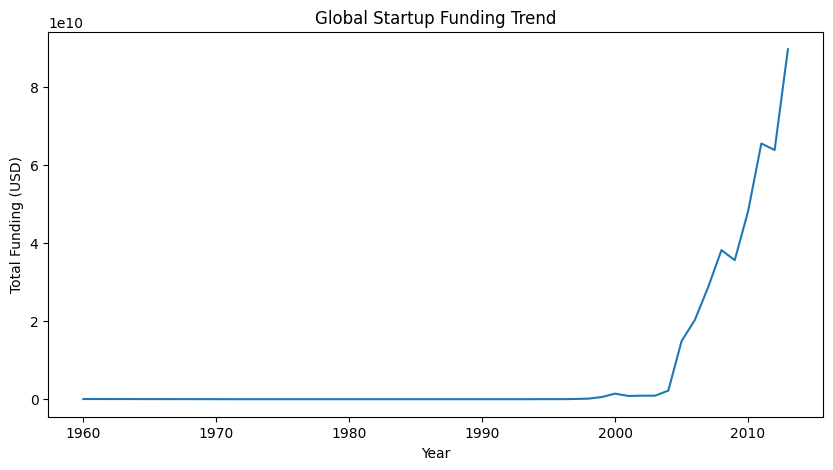

In [29]:
plt.figure(figsize=(10,5))
plt.plot(funding_trend.index, funding_trend.values)

plt.title("Global Startup Funding Trend")
plt.xlabel("Year")
plt.ylabel("Total Funding (USD)")

plt.show()

In [30]:
## Top Startup Industries
# Identifying sectors with highest funding.

In [31]:
top_sectors = startup_funding.groupby('category_code')['raised_amount_usd'].sum().sort_values(ascending=False).head(10)

top_sectors         


category_code
biotech        6.686868e+10
software       4.176832e+10
cleantech      3.867019e+10
mobile         2.989867e+10
enterprise     2.134636e+10
web            1.891835e+10
ecommerce      1.762815e+10
hardware       1.496217e+10
games_video    1.472512e+10
medical        1.323517e+10
Name: raised_amount_usd, dtype: float64

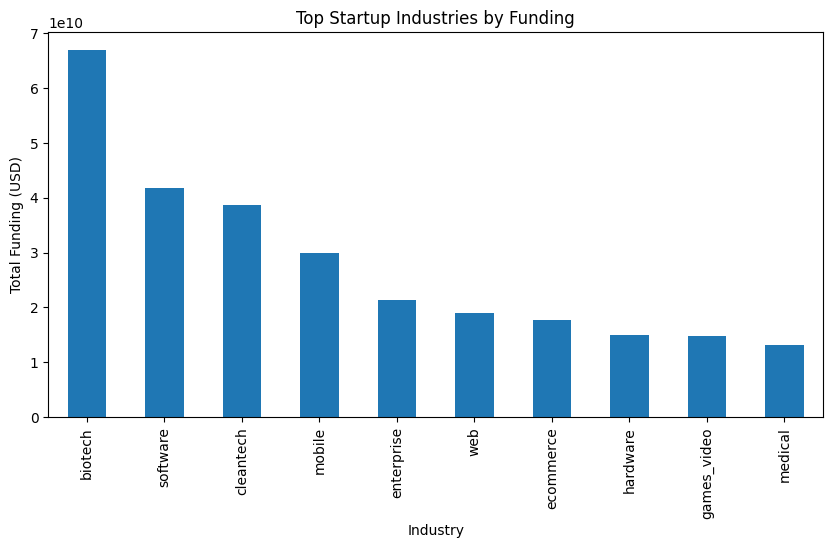

In [32]:
plt.figure(figsize=(10,5))
top_sectors.plot(kind='bar')

plt.title("Top Startup Industries by Funding")
plt.xlabel("Industry")
plt.ylabel("Total Funding (USD)")

plt.show()

In [33]:
## Top Countries
# Analyzing global startup hubs.

In [34]:
top_countries = startup_funding.groupby('country_code')['raised_amount_usd'].sum().sort_values(ascending=False).head(10)

top_countries

country_code
USA    3.105884e+11
GBR    1.770562e+10
CHN    1.068974e+10
CAN    9.866362e+09
IND    6.141410e+09
DEU    5.765774e+09
FRA    4.595138e+09
ISR    4.480092e+09
CHE    2.829253e+09
NLD    2.353969e+09
Name: raised_amount_usd, dtype: float64

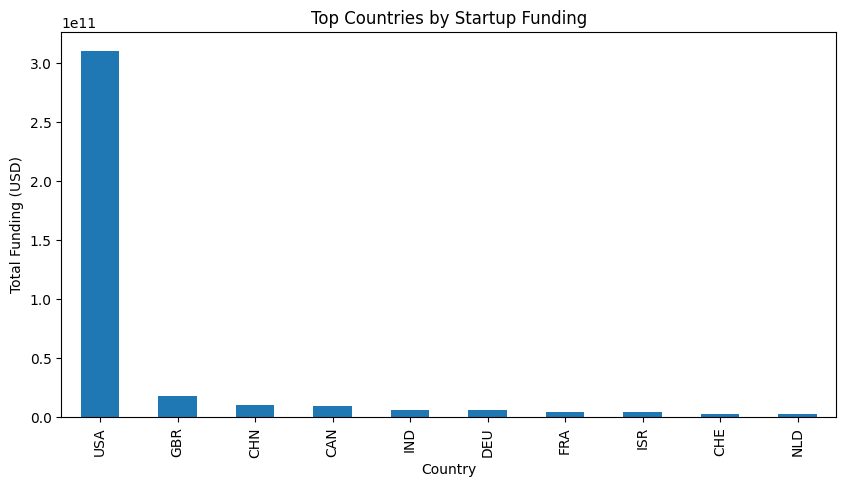

In [35]:
plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')

plt.title("Top Countries by Startup Funding")
plt.xlabel("Country")
plt.ylabel("Total Funding (USD)")

plt.show()

In [36]:
## Funding Round Analysis
# Understanding different stages of startup investments.

In [37]:
funding_rounds = startup_funding['funding_round_type'].value_counts()

funding_rounds

funding_round_type
venture           15265
angel             13051
series-a           9819
series-b           4865
series-c+          4197
other              4190
private-equity     1043
crowdfunding        111
post-ipo             85
Name: count, dtype: int64

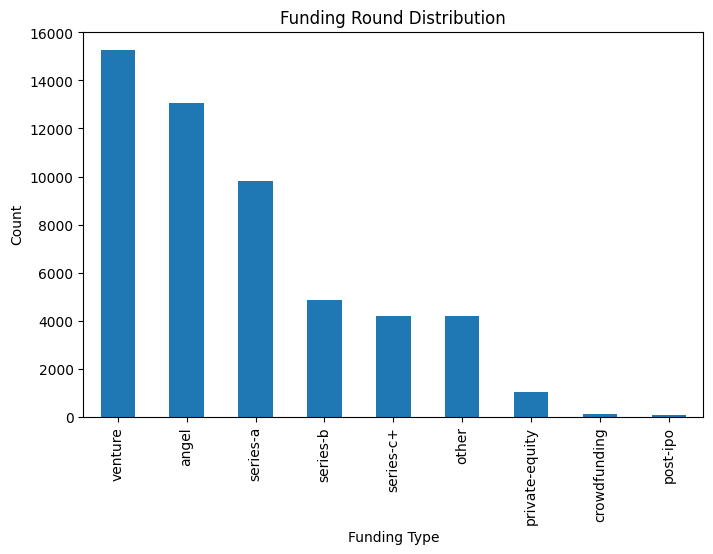

In [38]:
plt.figure(figsize=(8,5))
funding_rounds.plot(kind='bar')

plt.title("Funding Round Distribution")
plt.xlabel("Funding Type")
plt.ylabel("Count")

plt.show()

In [39]:
## Top Startup Industries
# Identifying sectors receiving highest funding.

In [40]:
top_sectors = (
    startup_funding.groupby('category_code')['raised_amount_usd']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sectors

category_code
biotech        6.686868e+10
software       4.176832e+10
cleantech      3.867019e+10
mobile         2.989867e+10
enterprise     2.134636e+10
web            1.891835e+10
ecommerce      1.762815e+10
hardware       1.496217e+10
games_video    1.472512e+10
medical        1.323517e+10
Name: raised_amount_usd, dtype: float64

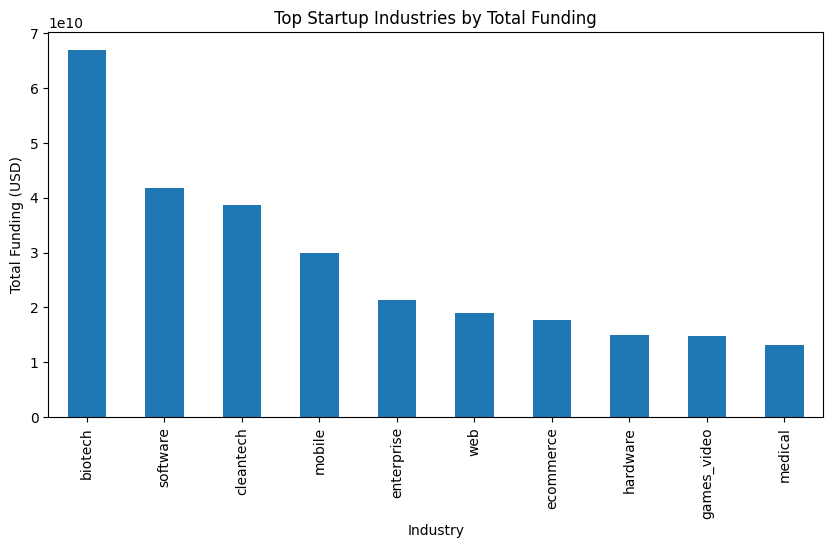

In [41]:
plt.figure(figsize=(10,5))
top_sectors.plot(kind='bar')

plt.title("Top Startup Industries by Total Funding")
plt.xlabel("Industry")
plt.ylabel("Total Funding (USD)")

plt.show()

In [42]:
funding_rounds = startup_funding['funding_round_type'].value_counts()

funding_rounds

funding_round_type
venture           15265
angel             13051
series-a           9819
series-b           4865
series-c+          4197
other              4190
private-equity     1043
crowdfunding        111
post-ipo             85
Name: count, dtype: int64

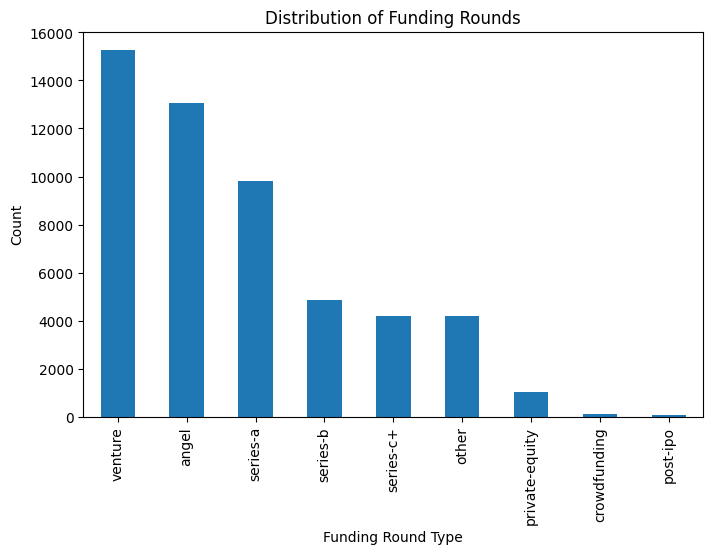

In [43]:
plt.figure(figsize=(8,5))
funding_rounds.plot(kind='bar')

plt.title("Distribution of Funding Rounds")
plt.xlabel("Funding Round Type")
plt.ylabel("Count")

plt.show()

In [44]:
## Average Funding by Industry
# Analyzing average investment per startup.

In [45]:
avg_funding_sector = (
    startup_funding.groupby('category_code')['raised_amount_usd']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_funding_sector

category_code
automotive          2.205043e+07
government          2.058196e+07
cleantech           1.971963e+07
nanotech            1.469585e+07
network_hosting     1.389730e+07
public_relations    1.193128e+07
semiconductor       1.186331e+07
biotech             1.118018e+07
manufacturing       1.070612e+07
transportation      1.005005e+07
Name: raised_amount_usd, dtype: float64

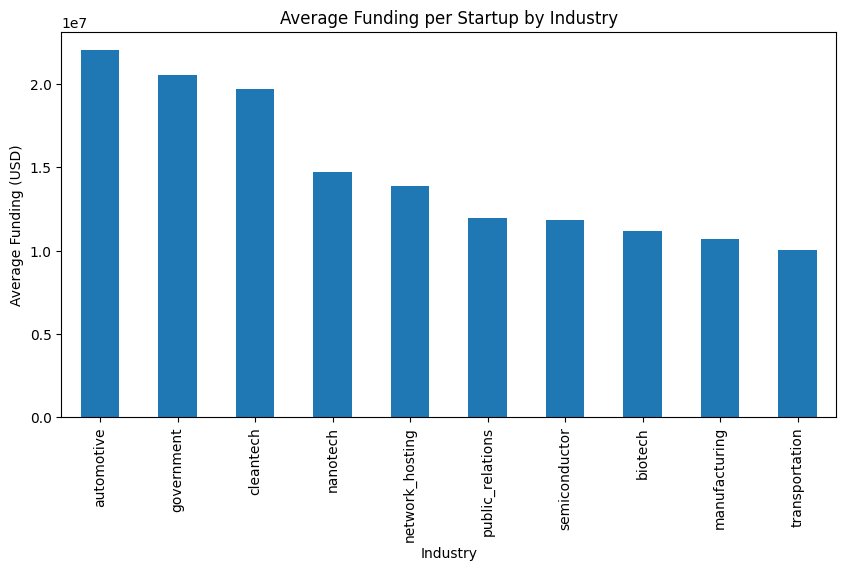

In [46]:
plt.figure(figsize=(10,5))
avg_funding_sector.plot(kind='bar')

plt.title("Average Funding per Startup by Industry")
plt.xlabel("Industry")
plt.ylabel("Average Funding (USD)")

plt.show()

In [47]:
## Top Investors
# Identifying major venture capital firms.

In [48]:
top_investors = (
    investments.groupby('investor_object_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_investors

investor_object_id
f:367     529
f:316     515
f:17      507
f:3181    484
f:4       480
f:41      478
c:2520    478
f:26      462
f:5928    364
f:29      361
dtype: int64

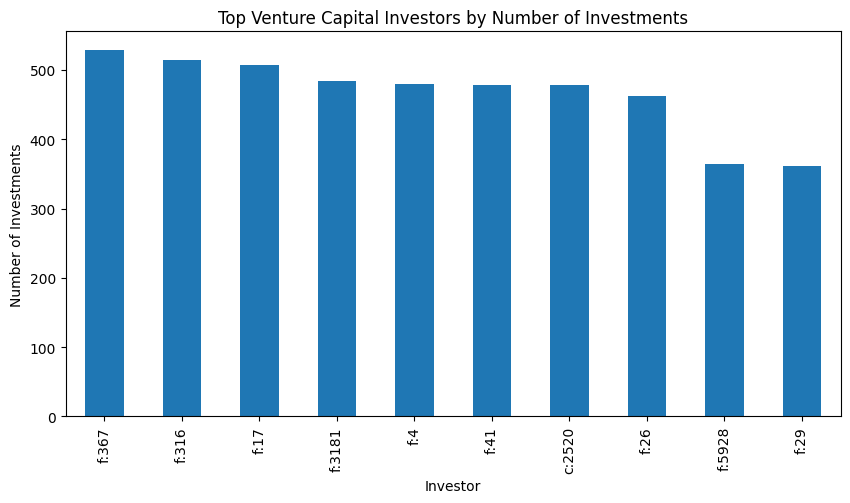

In [49]:
plt.figure(figsize=(10,5))
top_investors.plot(kind='bar')

plt.title("Top Venture Capital Investors by Number of Investments")
plt.xlabel("Investor")
plt.ylabel("Number of Investments")

plt.show()

In [50]:
## Global Funding Trend
##Total startup investment over time.

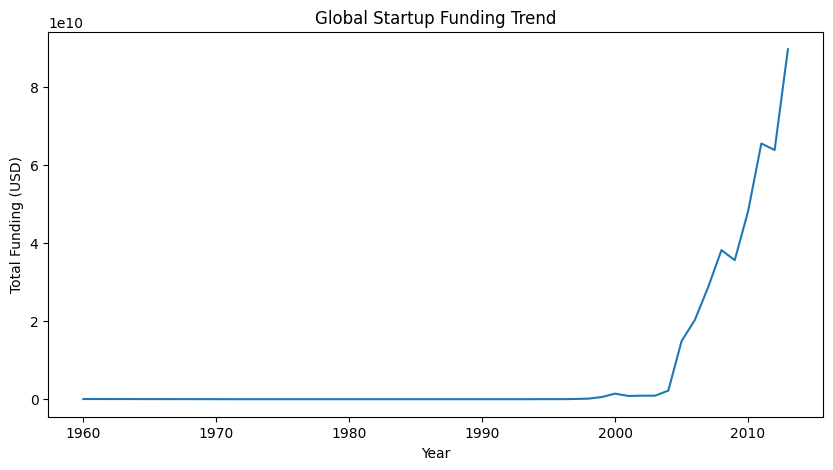

In [51]:
funding_trend = startup_funding.groupby('funding_year')['raised_amount_usd'].sum()

plt.figure(figsize=(10,5))
plt.plot(funding_trend.index, funding_trend.values)

plt.title("Global Startup Funding Trend")
plt.xlabel("Year")
plt.ylabel("Total Funding (USD)")

plt.show()

In [52]:
## Funding Growth Rate
# Year-over-year growth in startup funding.

In [53]:
funding_trend = (
    startup_funding.groupby('funding_year')['raised_amount_usd']
    .sum()
)

In [54]:
funding_growth = funding_trend.pct_change() * 100

funding_growth

funding_year
1960.0             NaN
1973.0   -1.000000e+02
1974.0             NaN
1984.0             inf
1985.0   -1.000000e+02
1987.0             inf
1989.0   -9.940000e+01
1990.0    6.566667e+03
1992.0    1.000000e+02
1993.0   -9.375000e+01
1994.0    1.062000e+04
1995.0    2.910448e+01
1996.0   -2.171965e+01
1997.0    3.771645e+02
1998.0    1.369839e+02
1999.0    2.682526e+02
2000.0    1.545826e+02
2001.0   -4.192051e+01
2002.0    8.833580e+00
2003.0   -2.844967e-01
2004.0    1.431141e+02
2005.0    5.767251e+02
2006.0    3.653418e+01
2007.0    4.125992e+01
2008.0    3.308091e+01
2009.0   -6.728231e+00
2010.0    3.501309e+01
2011.0    3.619019e+01
2012.0   -2.557317e+00
2013.0    4.046354e+01
Name: raised_amount_usd, dtype: float64

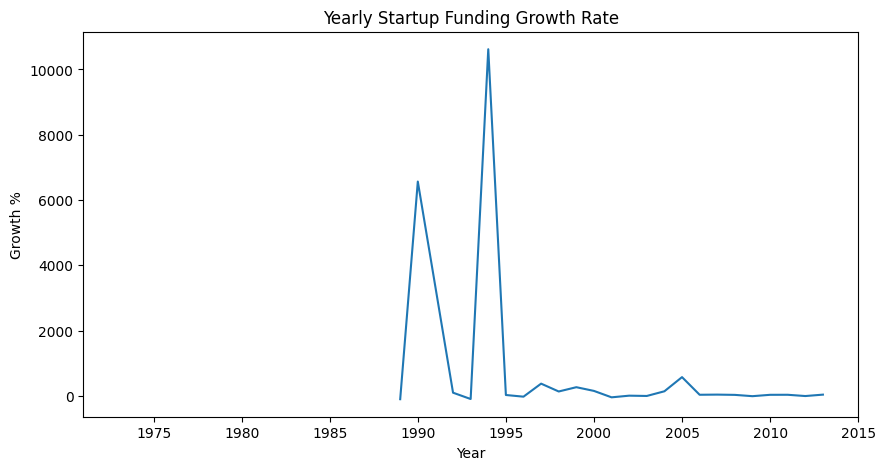

In [55]:
plt.figure(figsize=(10,5))
plt.plot(funding_growth.index, funding_growth.values)

plt.title("Yearly Startup Funding Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth %")

plt.show()

In [56]:
## Top Startup Cities
# Cities attracting highest investments.

In [57]:
top_cities = (
    startup_funding.groupby('city')['raised_amount_usd']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cities

city
San Francisco    2.473930e+10
New York         2.448251e+10
Palo Alto        9.177730e+09
Cambridge        8.478045e+09
San Diego        8.344047e+09
San Jose         7.866961e+09
Mountain View    7.843107e+09
Sunnyvale        7.019475e+09
Redwood City     6.802630e+09
London           5.974809e+09
Name: raised_amount_usd, dtype: float64

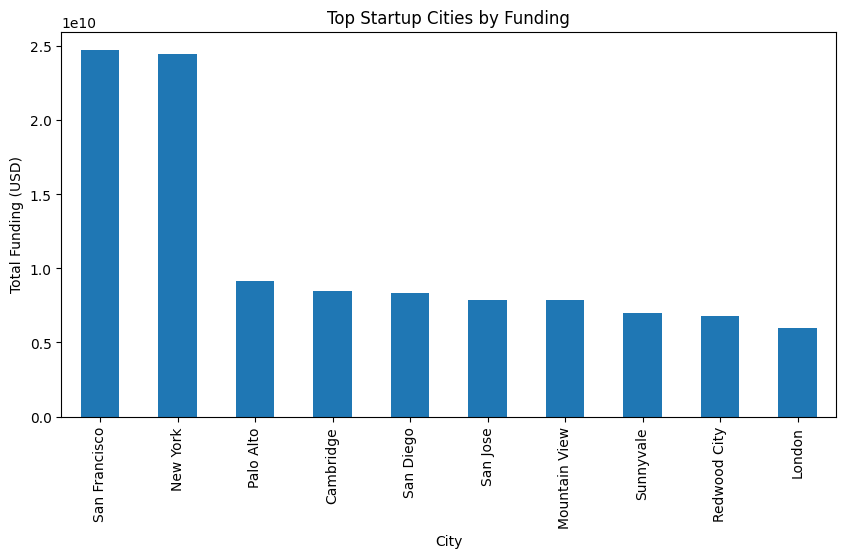

In [58]:
plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')

plt.title("Top Startup Cities by Funding")
plt.xlabel("City")
plt.ylabel("Total Funding (USD)")

plt.show()

In [59]:
## Key Metrics
# Overall startup ecosystem statistics.

In [60]:
total_funding = startup_funding['raised_amount_usd'].sum()
total_startups = startup_funding['object_id'].nunique()
total_investors = investments['investor_object_id'].nunique()
avg_funding = startup_funding['raised_amount_usd'].mean()

print("Total Funding Raised:", total_funding)
print("Total Startups Funded:", total_startups)
print("Total Investors:", total_investors)
print("Average Funding per Startup:", avg_funding)

Total Funding Raised: 412995690223.0
Total Startups Funded: 31707
Total Investors: 17152
Average Funding per Startup: 7847749.975734428


In [61]:
## Key Insights & Conclusion

#- Startup funding has increased significantly over time  
#-Technology sectors dominate global investments  
#- USA leads as the top startup hub  
#- Venture capital activity is concentrated among top investors

In [64]:
cols = ['object_id', 'city', 'country_code', 'raised_amount_usd']
startup_small = startup_funding[cols]

In [65]:
startup_small = startup_small.sample(n=10000, random_state=42)

In [66]:
startup_small.to_csv("startup_cleaned_small.csv", index=False)